In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/iabhishekofficial/mobile-price-classification/train.csv
/kaggle/input/datasets/iabhishekofficial/mobile-price-classification/test.csv


In [2]:
import pandas as pd #uvoz knjiznice pandas za delo s podatki

#nalozim podatke iz datoteke trian.csv
data=pd.read_csv("/kaggle/input/datasets/iabhishekofficial/mobile-price-classification/train.csv")
data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
#pregled podatke
data.shape #dobim stevilo vrstice in stolpcev
data.columns #dobim imena vseh stolpcev
data.info() #osnovne informacije o podatkih


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [4]:
data["price_range"].value_counts() #preverim porazdelitev ciljnega razreda(targeta)

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [5]:
data.describe()#osnovna statostika

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


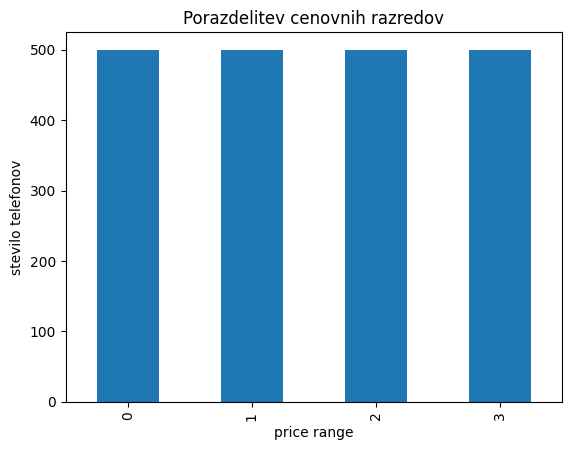

In [6]:
#vizuelni prikaz(porazdelitev cenovnih razredov)
import matplotlib.pyplot as bplot

data["price_range"].value_counts().sort_index().plot(kind="bar")
bplot.title("Porazdelitev cenovnih razredov")
bplot.xlabel("price range")
bplot.ylabel("stevilo telefonov")
bplot.show()

In [7]:
x=data.drop("price_range", axis=1) #vhodni podatki: vse stolpce razen price_range(target)
y=data["price_range"] #price_range je target

In [8]:
print(x.shape)
print(y.shape)

(2000, 20)
(2000,)


In [9]:
#razdelitev podatkov na ucni in tesni mnozici
from sklearn.model_selection import train_test_split

x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [10]:
print(x_train.shape)
print(y_train.shape)
print(y_test.shape)
print(x_test.shape)

(1600, 20)
(1600,)
(400,)
(400, 20)


In [11]:
#Decision Tree model
from sklearn.tree import DecisionTreeClassifier

dectr=DecisionTreeClassifier(random_state=42)
dectr.fit(x_train, y_train)#treniram model (features, correct class)

DecisionTreeClassifier(random_state=42)

In [12]:
#napovedovanje na testni mnozici
napy=dectr.predict(x_test)

In [13]:
print(napy[:7])#prikazujem prvih 7 napovedi

[3 2 0 2 3 2 0]


In [14]:
#ocenujem modela DT
from sklearn.metrics import accuracy_score
accdect=accuracy_score(y_test, napy)
print("DT accuracy:", accdect)

DT accuracy: 0.83


In [15]:
#katere razrede model pogosto zamenjuje(Confusion matrix)
from sklearn.metrics import confusion_matrix
conm=confusion_matrix(y_test, napy)
print(conm)

[[92  8  0  0]
 [13 74 13  0]
 [ 0 13 80  7]
 [ 0  0 14 86]]


In [16]:
#podrobna ocena modela DT
from sklearn.metrics import classification_report
cr=classification_report(y_test,napy)
print(cr)

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       100
           1       0.78      0.74      0.76       100
           2       0.75      0.80      0.77       100
           3       0.92      0.86      0.89       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



In [17]:
#Random Forest model
from sklearn.ensemble import RandomForestClassifier
randf=RandomForestClassifier(n_estimators=100, random_state=42)#zberem si 100 dreves za uporabo ker je pogosta zacetna izbira
randf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [18]:
#napovedovanje z Random Forest modelom
naprf=randf.predict(x_test)
print(naprf[:7])

[3 1 0 2 3 2 0]


In [19]:
#ocenujem model RF
accrandf=accuracy_score(y_test,naprf)
print("RF accuracy:", accrandf)

RF accuracy: 0.88


In [20]:
#matrika zamenjav za Random Forest
conmrf=confusion_matrix(y_test, naprf)
print(conmrf)

[[96  4  0  0]
 [ 5 84 11  0]
 [ 0 14 79  7]
 [ 0  0  7 93]]


In [21]:
#classification report (podrobna ocena modela RF)
crrf=classification_report(y_test, naprf)
print(crrf)

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.82      0.84      0.83       100
           2       0.81      0.79      0.80       100
           3       0.93      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



In [22]:
#primerjava natančnosti (DT in RF)
import pandas as accplot
accprimerjava=accplot.DataFrame({"Model":["Decision Tree", "Random Forest"], "Accuracy":[accdect, accrandf]})
accprimerjava

,Model,Accuracy
0,Decision Tree,0.83
1,Random Forest,0.88


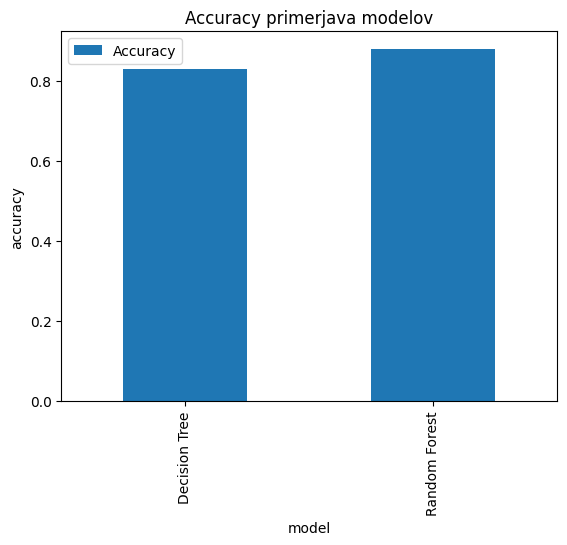

In [23]:
#vizuelna primerjava natancnosti modelov
import matplotlib.pyplot as acplot
accprimerjava.plot(x="Model",y="Accuracy",kind="bar")
acplot.title("Accuracy primerjava modelov")
acplot.xlabel("model")
acplot.ylabel("accuracy")
acplot.show()

In [24]:
#standardizacija podatkov za MLP model
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
xtrainsc=sc.fit_transform(x_train)
xtestsc=sc.transform(x_test)

In [25]:
#Nevronska mreža (MLP)
from sklearn.neural_network import MLPClassifier

mlp=MLPClassifier(hidden_layer_sizes=(50,),max_iter=500,random_state=42)
mlp.fit(xtrainsc, y_train)


MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)

In [26]:
#napovedovanje z MLP modelom

napmlp=mlp.predict(xtestsc)
print(napmlp[:7])

[3 1 0 2 3 2 0]


In [27]:
#ocenujem MLP model
accmlp=accuracy_score(y_test, napmlp)
print("MLP accuracy:", accmlp)

MLP accuracy: 0.915


In [28]:
#matrika zamenjav MLP
cmmlp=confusion_matrix(y_test, napmlp)
print(cmmlp)

[[93  7  0  0]
 [ 5 90  5  0]
 [ 0  2 92  6]
 [ 0  0  9 91]]


In [29]:
#podrobna ocena MLP modela
crmlp=classification_report(y_test,napmlp)
print(crmlp)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       100
           1       0.91      0.90      0.90       100
           2       0.87      0.92      0.89       100
           3       0.94      0.91      0.92       100

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



In [30]:
#primerjava vseh modelov 
primerjavavse=accplot.DataFrame({ "Model":["Decision Tree", "Random Forest", "MLP"], "Accuracy":[accdect, accrandf, accmlp]})
primerjavavse

,Model,Accuracy
0,Decision Tree,0.830
1,Random Forest,0.880
2,MLP,0.915


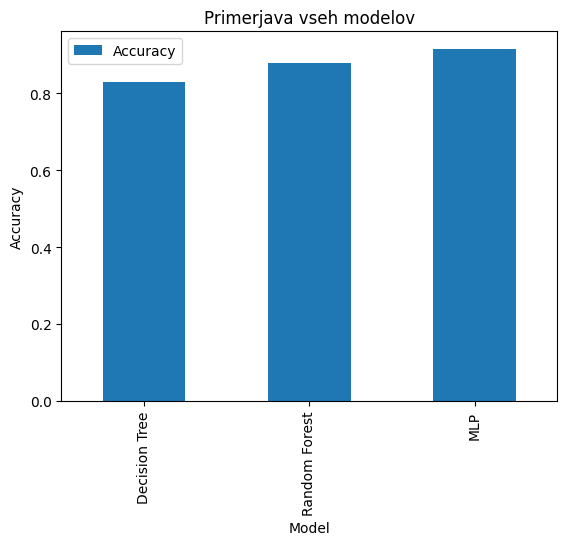

In [31]:
#vizuelna primerjava vseh modelov
primerjavavse.plot (x="Model", y="Accuracy", kind="bar")
acplot.title("Primerjava vseh modelov")
acplot.xlabel("Model")
acplot.ylabel("Accuracy")
acplot.show()

In [32]:
#dodatna analiza
#pomembnost znacilk pri Random Forest modelu
featureimp=accplot.DataFrame({"Feature": x.columns, "Importance": randf.feature_importances_})
featureimp=featureimp.sort_values(by="Importance", ascending=False)
featureimp.head(7)

,Feature,Importance
13,ram,0.480768
0,battery_power,0.072976
12,px_width,0.056089
11,px_height,0.056000
8,mobile_wt,0.039007
6,int_memory,0.034837
16,talk_time,0.031891


In [33]:
#Analiza uspesnosti modela na učnih in testnih podatkih
#Decision Tree
trainaccdt=dectr.score(x_train,y_train)
print("Train accuracy:", trainaccdt)
print("Test accuracy:", accdect)

Train accuracy: 1.0
Test accuracy: 0.83


In [34]:
#Random Forest
trainaccrf=randf.score(x_train,y_train)
print("Train accuracy:", trainaccrf)
print("Test accuracy:", accrandf)

Train accuracy: 1.0
Test accuracy: 0.88


In [35]:
#MLP
trainaccmlp=mlp.score(xtrainsc,y_train)
print("Train accuracy:", trainaccmlp)
print("Test accuracy:", accmlp)

Train accuracy: 1.0
Test accuracy: 0.915


In [36]:
#Dodatno:zmanjsanje overffittinga

#Izboljsam DT z omejeno globino
dectr2=DecisionTreeClassifier(max_depth=6, random_state=42)
dectr2.fit(x_train,y_train)
napdt2=dectr2.predict(x_test)
accdt2=accuracy_score(y_test,napdt2)

trainaccdt2=dectr2.score(x_train,y_train)
print("Train accuracy:", trainaccdt2)
print("Test accuracy:", accdt2)

Train accuracy: 0.92375
Test accuracy: 0.845


In [37]:
#Izboljsam RF z omejeno globino
randf2=RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
randf2.fit(x_train,y_train)
naprf2=randf2.predict(x_test)
accrf2=accuracy_score(y_test,naprf2)

trainaccrf2=randf2.score(x_train,y_train)
print("Train accuracy:", trainaccrf2)
print("Test accuracy:", accrf2)

Train accuracy: 0.999375
Test accuracy: 0.89


In [38]:
#Izboljsam MLP z regulacijo
mlp2=MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42, alpha=2)
mlp2.fit(xtrainsc,y_train)
napmlp2=mlp2.predict(xtestsc)
accmlp2=accuracy_score(y_test,napmlp2)

trainaccmlp2=mlp2.score(xtrainsc,y_train)
print("Train accuracy:", trainaccmlp2)
print("Test accuracy:", accmlp2)

Train accuracy: 0.980625
Test accuracy: 0.97


In [39]:
#primerjava izboljsanih modelov
izboljsanevse=accplot.DataFrame({ "Model":["Decision Tree", "Random Forest", "MLP"], "Accuracy":[accdt2, accrf2, accmlp2]})
izboljsanevse

,Model,Accuracy
0,Decision Tree,0.845
1,Random Forest,0.890
2,MLP,0.970


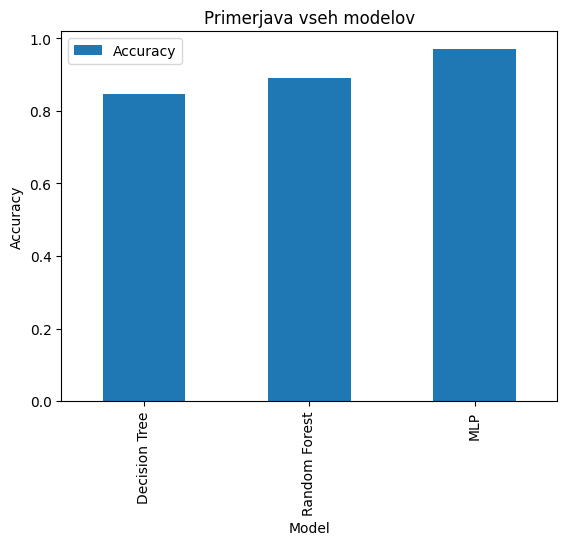

In [40]:
# Vizualna primerjava izboljšsanih modelov
izboljsanevse.plot (x="Model", y="Accuracy", kind="bar")
acplot.title("Primerjava vseh modelov")
acplot.xlabel("Model")
acplot.ylabel("Accuracy")
acplot.show()